Soil Classification with MobileNetV2

soil image classification

In [4]:
# Import required libraries
import tensorflow as tf
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.layers import GlobalAveragePooling2D, Dense, Dropout
from tensorflow.keras.models import Sequential
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint, ReduceLROnPlateau
import numpy as np
import matplotlib.pyplot as plt
import os

# Step 1: Data Preparation
data_dir = "soilimg_dataset\Train"
img_size = (224, 224)  # MobileNetV2 default input size
batch_size = 32

# Data augmentation and preprocessing
train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=40,
    width_shift_range=0.2,
    height_shift_range=0.2,
    shear_range=0.2,
    zoom_range=0.2,
    horizontal_flip=True,
    vertical_flip=True,
    brightness_range=[0.8, 1.2],
    fill_mode='nearest',
    validation_split=0.2  # 20% for validation
)

# Training data generator
train_generator = train_datagen.flow_from_directory(
    data_dir,
    target_size=img_size,
    batch_size=batch_size,
    class_mode='categorical',
    subset='training',
    shuffle=True
)

# Validation data generator
val_generator = train_datagen.flow_from_directory(
    data_dir,
    target_size=img_size,
    batch_size=batch_size,
    class_mode='categorical',
    subset='validation',
    shuffle=False
)

# Check class indices
print("Class Indices:", train_generator.class_indices)

# Visualize sample images
def plot_sample_images():
    images, labels = next(train_generator)
    plt.figure(figsize=(12, 9))
    for i in range(9):
        plt.subplot(3, 3, i+1)
        plt.imshow(images[i])
        plt.title(list(train_generator.class_indices.keys())[np.argmax(labels[i])])
        plt.axis('off')
    plt.tight_layout()
    plt.show()

plot_sample_images()

# Step 2: Model Building with MobileNetV2
def create_model():
    # Load pre-trained MobileNetV2
    base_model = MobileNetV2(
        weights='imagenet',
        include_top=False,
        input_shape=(224, 224, 3)
    )
    
    # Freeze the base model
    base_model.trainable = False
    
    # Build custom classifier
    model = Sequential([
        base_model,
        GlobalAveragePooling2D(),
        Dense(128, activation='relu'),
        Dropout(0.5),
        Dense(4, activation='softmax')  # 4 soil classes
    ])
    
    # Compile the model
    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=0.0001),
        loss='categorical_crossentropy',
        metrics=['accuracy']
    )
    
    return model

model = create_model()
model.summary()

# Step 3: Training Configuration
callbacks = [
    EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True),
    ModelCheckpoint('best_mobilenet_model.h5', monitor='val_accuracy', save_best_only=True),
    ReduceLROnPlateau(monitor='val_loss', factor=0.1, patience=3)
]

# Step 4: Model Training
history = model.fit(
    train_generator,
    epochs=50,
    validation_data=val_generator,
    callbacks=callbacks
)

# Step 5: Evaluation
def plot_training_history(history):
    acc = history.history['accuracy']
    val_acc = history.history['val_accuracy']
    loss = history.history['loss']
    val_loss = history.history['val_loss']
    
    plt.figure(figsize=(12, 5))
    plt.subplot(1, 2, 1)
    plt.plot(acc, label='Training Accuracy')
    plt.plot(val_acc, label='Validation Accuracy')
    plt.title('Training and Validation Accuracy')
    plt.legend()
    
    plt.subplot(1, 2, 2)
    plt.plot(loss, label='Training Loss')
    plt.plot(val_loss, label='Validation Loss')
    plt.title('Training and Validation Loss')
    plt.legend()
    plt.show()

plot_training_history(history)

# Step 6: Prediction Function
def predict_soil_class(img_path, model):
    img = tf.keras.preprocessing.image.load_img(img_path, target_size=img_size)
    img_array = tf.keras.preprocessing.image.img_to_array(img)
    img_array = np.expand_dims(img_array, axis=0) / 255.0
    
    pred = model.predict(img_array)
    predicted_class = np.argmax(pred)
    confidence = np.max(pred)
    
    class_names = list(train_generator.class_indices.keys())
    return class_names[predicted_class], confidence

# Example usage
test_image_path = "soilimg_dataset\Test\Alluvial_soil\Alluvial_9.jpg"  #  image path
pred_class, confidence = predict_soil_class(test_image_path, model)
print(f"Predicted Class: {pred_class} (Confidence: {confidence:.2f})")

# Step 7: Fine-tuning (Optional for better performance)
def fine_tune_model(model):
    # Unfreeze top layers of base model
    model.layers[0].trainable = True
    
    # Fine-tune only the last 50 layers
    for layer in model.layers[0].layers[:-50]:
        layer.trainable = False
    
    # Recompile with lower learning rate
    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=1e-5),
        loss='categorical_crossentropy',
        metrics=['accuracy']
    )
    return model

# Uncomment to fine-tune
# model = fine_tune_model(model)
# history_fine = model.fit(
#     train_generator,
#     epochs=20,
#     validation_data=val_generator,
#     callbacks=callbacks
# )
# plot_training_history(history_fine)

FileNotFoundError: [WinError 3] The system cannot find the path specified: 'soilimg_dataset\\Train'

In [ ]:
from tensorflow.keras.models import load_model
import numpy as np
from tensorflow.keras.preprocessing import image

# Load the best saved model
model = load_model('best_mobilenet_model.h5')  # or 'best_model.h5' from earlier

ValueError: Unrecognized keyword arguments: ['batch_shape']

In [ ]:
def predict_soil(image_path, model):
    # Load and preprocess the image
    img = image.load_img(image_path, target_size=(224, 224))
    img_array = image.img_to_array(img)
    img_array = np.expand_dims(img_array, axis=0) / 255.0  # Normalize
    
    # Make prediction
    pred = model.predict(img_array)
    predicted_class = np.argmax(pred)
    confidence = np.max(pred) * 100  # Convert to percentage
    
    # Get class names
    class_names = ['Alluvial_soil', 'Black_soil', 'Clay_soil', 'Lateritic_soil']  # Update if different
    
    return class_names[predicted_class], confidence

In [ ]:
# Example usage
image_path = "soilimg_dataset/Test/Alluvial_soil/Alluvial_8.jpg"  # Replace with your image
pred_class, confidence = predict_soil(image_path, model)
print(f"Predicted Soil Type: {pred_class}")
print(f"Confidence: {confidence:.2f}%")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step
Predicted Soil Type: Lateritic_soil
Confidence: 82.56%


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step


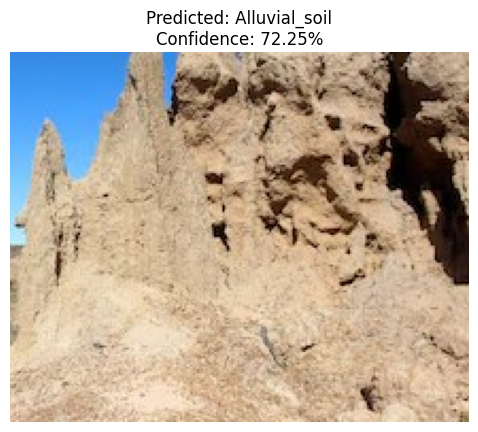

In [ ]:
import matplotlib.pyplot as plt

def show_prediction(image_path, model):
    pred_class, confidence = predict_soil(image_path, model)
    img = image.load_img(image_path)
    
    plt.imshow(img)
    plt.title(f"Predicted: {pred_class}\nConfidence: {confidence:.2f}%")
    plt.axis('off')
    plt.show()

# Example
show_prediction("soilimg_dataset\Test\Alluvial_soil\Alluvial_6.jpg", model)

In [ ]:
model.save('soil_classifier.h5')  # Saves architecture + weights + optimizer state

In [ ]:
from tensorflow.keras.models import load_model

# Load HDF5 model
loaded_model = load_model('soil_classifier.h5')

In [ ]:
import numpy as np
from tensorflow.keras.preprocessing import image

def predict_soil(image_path, model):
    # Load and preprocess image
    img = image.load_img(image_path, target_size=(224, 224))
    img_array = image.img_to_array(img)
    img_array = np.expand_dims(img_array, axis=0) / 255.0  # Normalize
    
    # Predict
    pred = model.predict(img_array)
    class_idx = np.argmax(pred)
    confidence = np.max(pred) * 100
    
    # Map to class names (update to match your classes)
    class_names = {
        0: 'Alluvial_soil',
        1: 'Black_soil', 
        2: 'Clay_soil',
        3: 'Red_soil'
    }
    
    return class_names[class_idx], confidence

In [ ]:
image_path = "soilimg_dataset\Test\Clay_soil\Clay_18.jpg"
class_name, confidence = predict_soil(image_path, loaded_model)
print(f"Predicted: {class_name} (Confidence: {confidence:.2f}%)")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step
Predicted: Clay_soil (Confidence: 99.80%)
